In [ ]:
import pandas as pd

df = pd.read_csv('data/raw/datos_crudos.csv')
df.head()


,Unnamed: 0,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento,departamento_nom,ciudad_municipio,ciudad_municipio_nom,edad,unidad_medida,...,recuperado,fecha_inicio_sintomas,fecha_muerte,fecha_diagnostico,per_etn_,fecha_recuperado,tipo_recuperacion,nom_grupo_,pais_viajo_1_cod,pais_viajo_1_nom
0,0,2020-05-03 00:00:00,7597,2020-04-29 00:00:00,11,BOGOTA,11001,BOGOTA,69,1,...,Recuperado,2020-04-24 00:00:00,NaN,2020-05-03 00:00:00,5.0,2020-05-29 00:00:00,PCR,NaN,NaN,NaN
1,1,2020-05-13 00:00:00,12537,2020-05-07 00:00:00,91,AMAZONAS,91001,LETICIA,51,1,...,Recuperado,2020-05-03 00:00:00,NaN,2020-05-13 00:00:00,1.0,2020-06-04 00:00:00,Tiempo,TIKUNA,NaN,NaN
2,2,2020-05-13 00:00:00,12869,2020-05-08 00:00:00,11,BOGOTA,11001,BOGOTA,72,1,...,Recuperado,2020-05-08 00:00:00,NaN,2020-05-13 00:00:00,6.0,2020-05-23 00:00:00,PCR,NaN,NaN,NaN
3,3,2020-06-13 00:00:00,47472,2020-05-29 00:00:00,13001,CARTAGENA,13001,CARTAGENA,31,1,...,Recuperado,2020-05-25 00:00:00,NaN,2020-06-13 00:00:00,6.0,2020-06-26 00:00:00,PCR,NaN,NaN,NaN
4,4,2020-06-20 00:00:00,64066,2020-06-16 00:00:00,11,BOGOTA,11001,BOGOTA,26,1,...,Recuperado,2020-06-05 00:00:00,NaN,2020-06-20 00:00:00,6.0,2020-07-04 00:00:00,PCR,NaN,NaN,NaN


In [2]:
df['departamento_nom'].unique()
# Dado que Santa Marta y Cartagena se consideran distritos especiales, se fusionaran con Magdalena y Bolivar, respectivamente
cambios= {'BARRANQUILLA':'ATLANTICO','STA MARTA D.E.':'MAGDALENA','CARTAGENA':'BOLIVAR'}
df['departamento_nom']=df['departamento_nom'].replace(cambios)

df.drop('departamento',axis=1, inplace=True)
df.drop('ciudad_municipio',axis=1, inplace=True)
df.drop('ciudad_municipio_nom',axis=1, inplace=True)
df.head()

,Unnamed: 0,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento_nom,edad,unidad_medida,sexo,fuente_tipo_contagio,ubicacion,...,recuperado,fecha_inicio_sintomas,fecha_muerte,fecha_diagnostico,per_etn_,fecha_recuperado,tipo_recuperacion,nom_grupo_,pais_viajo_1_cod,pais_viajo_1_nom
0,0,2020-05-03 00:00:00,7597,2020-04-29 00:00:00,BOGOTA,69,1,M,Comunitaria,Casa,...,Recuperado,2020-04-24 00:00:00,NaN,2020-05-03 00:00:00,5.0,2020-05-29 00:00:00,PCR,NaN,NaN,NaN
1,1,2020-05-13 00:00:00,12537,2020-05-07 00:00:00,AMAZONAS,51,1,M,Relacionado,Casa,...,Recuperado,2020-05-03 00:00:00,NaN,2020-05-13 00:00:00,1.0,2020-06-04 00:00:00,Tiempo,TIKUNA,NaN,NaN
2,2,2020-05-13 00:00:00,12869,2020-05-08 00:00:00,BOGOTA,72,1,M,Relacionado,Casa,...,Recuperado,2020-05-08 00:00:00,NaN,2020-05-13 00:00:00,6.0,2020-05-23 00:00:00,PCR,NaN,NaN,NaN
3,3,2020-06-13 00:00:00,47472,2020-05-29 00:00:00,BOLIVAR,31,1,F,Relacionado,Casa,...,Recuperado,2020-05-25 00:00:00,NaN,2020-06-13 00:00:00,6.0,2020-06-26 00:00:00,PCR,NaN,NaN,NaN
4,4,2020-06-20 00:00:00,64066,2020-06-16 00:00:00,BOGOTA,26,1,F,Relacionado,Casa,...,Recuperado,2020-06-05 00:00:00,NaN,2020-06-20 00:00:00,6.0,2020-07-04 00:00:00,PCR,NaN,NaN,NaN


Ahora, voy a responder unas preguntas con los datos quetengo....

In [3]:
df['fecha_reporte_web'].dtype
df['fecha_reporte_web']=pd.to_datetime(df['fecha_reporte_web'])
print(df['fecha_reporte_web'].dtype)
df1=df["fecha_reporte_web"].value_counts().sort_index()

df1

datetime64[us]


fecha_reporte_web
2020-03-28    1
2020-03-29    1
2020-03-30    1
2020-04-01    1
2020-04-02    1
             ..
2023-12-20    3
2023-12-26    1
2024-01-03    5
2024-01-10    2
2024-01-17    6
Name: count, Length: 812, dtype: int64

In [19]:
#df1=df1.sort_values()
#print(df1.columns)
#df1=df1.rename(columns={"Unnamed: 0":"datos-POR-fecha"})


Inicialmente: 

En que fehcasx ocurrieron los picos de pandemia

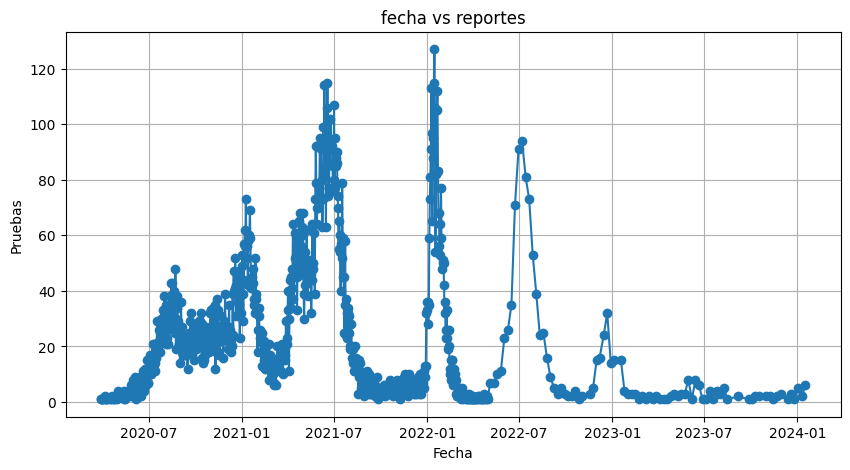

In [4]:
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('default')
x=df1

x1=x.index.tolist()
y1=x.tolist()

plt.figure(figsize=(10,5), facecolor='white')
plt.plot(x1, y1, marker='o')
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('Pruebas')
plt.grid(True)
plt.show()




Ahora, veremos como varia la cantidad de muertes a traves del tiempo

In [5]:
df.columns

Index(['Unnamed: 0', 'fecha_reporte_web', 'id_de_caso',
       'fecha_de_notificaci_n', 'departamento_nom', 'edad', 'unidad_medida',
       'sexo', 'fuente_tipo_contagio', 'ubicacion', 'estado', 'recuperado',
       'fecha_inicio_sintomas', 'fecha_muerte', 'fecha_diagnostico',
       'per_etn_', 'fecha_recuperado', 'tipo_recuperacion', 'nom_grupo_',
       'pais_viajo_1_cod', 'pais_viajo_1_nom'],
      dtype='str')

Primero buscamos que porcentaje de los casos en toda la pandemia son fallecidos


In [22]:
# BUSCAMOS LOS VALORES UNICOS DE LA COLUMNA "estado"
print('los valores unicos de la columna "estado" son:',df['estado'].unique())

# MEDIANTE UN GROUPBY SACAREMOS ESTAS CANTIDADES
df2=df
print(df2['estado'].dtype)
df2=df2['estado'].value_counts()
df2




los valores unicos de la columna "estado" son: <StringArray>
['Leve', 'Fallecido', 'leve', nan, 'Moderado']
Length: 5, dtype: str
str


estado
Leve         19264
Fallecido      459
leve           156
Moderado         4
Name: count, dtype: int64

Primero buscamos que porcentaje de los reportes son fallecidos

In [6]:
df3=df

df3=df.groupby(["fecha_reporte_web", "estado"]).size()
print(df3)




fecha_reporte_web  estado   
2020-03-28         Leve         1
2020-03-29         Leve         1
2020-03-30         Fallecido    1
2020-04-01         Leve         1
2020-04-02         Leve         1
                               ..
2024-01-03         Moderado     1
2024-01-10         Leve         1
                   Moderado     1
2024-01-17         Leve         5
                   Moderado     1
Length: 1137, dtype: int64


In [7]:
df3=df3.to_frame()

df3 = df3.reset_index()
df3=df3[['fecha_reporte_web','estado',0]]
df3.columns


Index(['fecha_reporte_web', 'estado', 0], dtype='object')

Ahora, vamos a sacar los fallecidos por fecha

In [8]:
#df3=df3[df3['estado']=='Fallecido']
df_fallecidos = df3[df3["estado"] == "Fallecido"]
df_fallecidos

,fecha_reporte_web,estado,0
2,2020-03-30,Fallecido,1
28,2020-05-13,Fallecido,1
37,2020-05-23,Fallecido,1
50,2020-06-04,Fallecido,1
59,2020-06-12,Fallecido,1
...,...,...,...
1059,2022-08-25,Fallecido,1
1069,2022-10-13,Fallecido,1
1078,2022-12-15,Fallecido,1
1083,2023-01-05,Fallecido,2


In [9]:
x3=df_fallecidos['fecha_reporte_web']
x2=df_fallecidos[0]





<Figure size 1000x500 with 0 Axes>

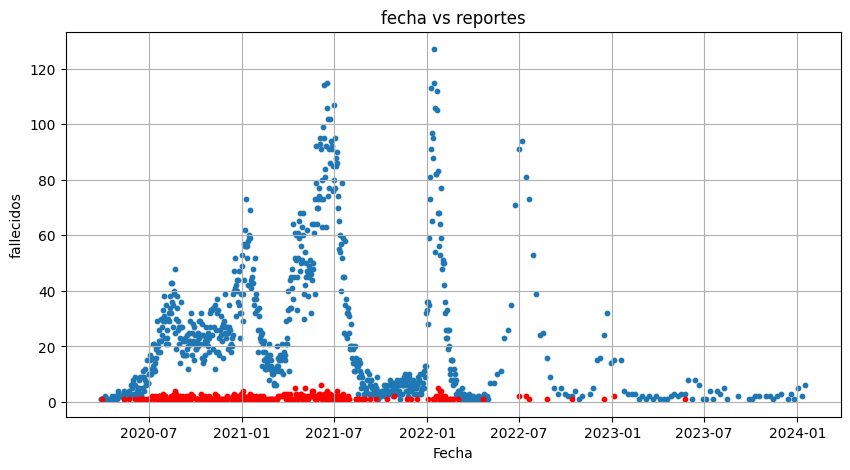

In [10]:
import matplotlib
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.figure(figsize=(10,5))
plt.scatter(x1, y1, marker='o',s=10)
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('Pruebas')
plt.grid(True)



plt.scatter(x3, x2, color='red',marker='o',s=10)
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('fallecidos')
plt.grid(True)
plt.show()

In [28]:
#'Unnamed: 0', 'fecha_reporte_web', 'id_de_caso',
#       'fecha_de_notificaci_n', 'departamento', 'departamento_nom',
#       'ciudad_municipio', 'ciudad_municipio_nom', 'edad', 'unidad_medida',
#       'sexo', 'fuente_tipo_contagio', 'ubicacion', 'estado', 'recuperado',
#       'fecha_inicio_sintomas', 'fecha_muerte', 'fecha_diagnostico',
#       'per_etn_', 'fecha_recuperado', 'tipo_recuperacion', 'nom_grupo_',
#       'pais_viajo_1_cod', 'pais_viajo_1_nom'],

/tmp/ipykernel_3989/1377972664.py:210: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


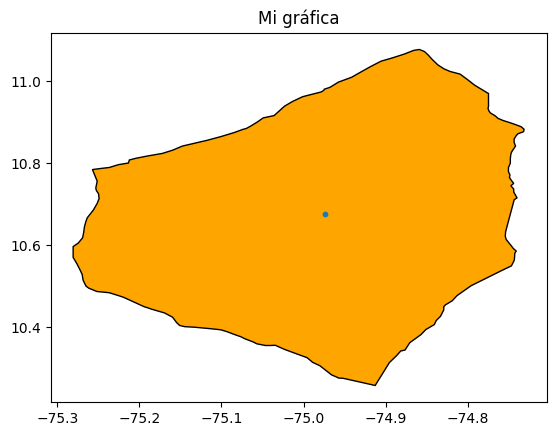

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


puntos=[[-74.87059783939971, 10.361200332569519],
      [-74.87640380852382, 10.343299865912297],
      [-74.88159942607246, 10.340999603370339],
      [-74.88670349132055, 10.329500198465997],
      [-74.89540100113972, 10.312700271692613],
      [-74.91271972648573, 10.256701469421614],
      [-74.95179748534133, 10.27429962167056],
      [-74.95760345477576, 10.274900436283982],
      [-74.95880126954732, 10.276599884086268],
      [-74.96569824236279, 10.282400131405682],
      [-74.98010253887253, 10.305000305151292],
      [-74.98880004879528, 10.313099861339909],
      [-74.99569702130941, 10.32470035565624],
      [-75.00839996321778, 10.333999633917488],
      [-75.02339935282973, 10.345100402703817],
      [-75.03430175779863, 10.354900360105775],
      [-75.04119873038658, 10.354399681142114],
      [-75.04640197733946, 10.354399680921732],
      [-75.05680084221738, 10.358499526824435],
      [-75.06140136707698, 10.363100051819199],
      [-75.07180023186307, 10.371199608009466],
      [-75.07640075668733, 10.375900268690785],
      [-75.08390045181022, 10.381099700927601],
      [-75.09310150164578, 10.388099670305978],
      [-75.10060119612035, 10.392700195486215],
      [-75.1057968140884, 10.393899917435466],
      [-75.11450195304411, 10.395700454530083],
      [-75.12079620342436, 10.396900176841603],
      [-75.12480926500072, 10.397626876905278],
      [-75.13349914538493, 10.399200439269212],
      [-75.14450073243258, 10.400400161917627],
      [-75.15080261244589, 10.403300285465935],
      [-75.15429687487836, 10.409700393809691],
      [-75.15950012189285, 10.423600196779537],
      [-75.16929626445068, 10.434000015405],
      [-75.18540191662493, 10.44340038306362],
      [-75.18939971919052, 10.446299552920827],
      [-75.1940994264758, 10.449199676378134],
      [-75.2015991209867, 10.456100463807834],
      [-75.2072982787371, 10.46129989610497],
      [-75.21939849858032, 10.472399711771448],
      [-75.22640228265163, 10.477000236406045],
      [-75.23670196539946, 10.483400345014225],
      [-75.25170135491194, 10.486399650571265],
      [-75.26149749758953, 10.494500160122776],
      [-75.26499938970332, 10.499699592593261],
      [-75.26850128178127, 10.514200210566129],
      [-75.26959991457737, 10.52799987789845],
      [-75.27189636241651, 10.537899970895465],
      [-75.27600097664377, 10.554100036461804],
      [-75.28060150146817, 10.56970024110065],
      [-75.2806015013251, 10.577799796949833],
      [-75.2806015015074, 10.595950126538554],
      [-75.28060150150654, 10.596199989477023],
      [-75.2742996214892, 10.604900360140931],
      [-75.26909637458004, 10.617600441064099],
      [-75.26789855950574, 10.629099845843355],
      [-75.26679992658786, 10.644700050508398],
      [-75.26509857170439, 10.657400131368993],
      [-75.26339721681012, 10.66660022755614],
      [-75.25589752205083, 10.68570041660483],
      [-75.25129699722176, 10.701800346280294],
      [-75.25026702898546, 10.707001685965386],
      [-75.24900054926945, 10.71339988708827],
      [-75.24960327158107, 10.724900245671671],
      [-75.2524032594168, 10.733599662677896],
      [-75.25299835223143, 10.739399909900818],
      [-75.25129699698307, 10.756099700881073],
      [-75.25710296632371, 10.784399986167102],
      [-75.24839782696093, 10.786700248791549],
      [-75.23629760721938, 10.789600372418821],
      [-75.2254028321473, 10.79640007038087],
      [-75.21330261226197, 10.800399780448153],
      [-75.2120971680437, 10.80790042860248],
      [-75.20410156257007, 10.8120002745174],
      [-75.1896972656558, 10.817700386084695],
      [-75.17179870588197, 10.823900222830856],
      [-75.15910339363067, 10.831999778846747],
      [-75.14759826643575, 10.841799735929618],
      [-75.11699676505268, 10.856100082248435],
      [-75.10030364997735, 10.865200042889812],
      [-75.08419799789644, 10.874999999978654],
      [-75.07330322257475, 10.88300037378955],
      [-75.06980133069753, 10.88469982137696],
      [-75.06400299088433, 10.891099929985526],
      [-75.05650329577084, 10.900300026056295],
      [-75.04910278314786, 10.910699844246656],
      [-75.03579711915758, 10.916399955861475],
      [-75.02310180652078, 10.939399719133815],
      [-75.01329803475006, 10.950900077703254],
      [-75.00119781482896, 10.9624004365161],
      [-74.99063110348288, 10.967923164239707],
      [-74.9787979126279, 10.97389984110649],
      [-74.97530364970585, 10.977899551525676],
      [-74.97470092770224, 10.980799674855744],
      [-74.96779632581836, 10.985400199845023],
      [-74.95749664292548, 10.998100280815095],
      [-74.94129943855742, 11.010100364666444],
      [-74.93329620368564, 11.019300460971948],
      [-74.91889953628223, 11.035499572901742],
      [-74.9056015016451, 11.049300193716004],
      [-74.89179992669763, 11.057299613838437],
      [-74.87680053726099, 11.067000389091831],
      [-74.86579895037706, 11.075699806336603],
      [-74.85890197770219, 11.077899932860914],
      [-74.85257720937093, 11.072692871188675],
      [-74.84799957265109, 11.064000129801544],
      [-74.8432998656076, 11.053600311307726],
      [-74.83942413332201, 11.046132087766676],
      [-74.83640289312874, 11.040300369100123],
      [-74.82890319813461, 11.030500411881853],
      [-74.82140350336917, 11.024100303484795],
      [-74.80930328358058, 11.017700195432583],
      [-74.80069732685736, 11.004899978715223],
      [-74.79139709463142, 10.990400314388552],
      [-74.77469635025216, 10.970199584970292],
      [-74.77469635014559, 10.958600044181019],
      [-74.77469635009685, 10.94880008702416],
      [-74.77469635028773, 10.939000129811605],
      [-74.77529907216233, 10.933799743714696],
      [-74.77488708512684, 10.931578636305359],
      [-74.77410125714161, 10.927399635363884],
      [-74.77239990236663, 10.92280006395492],
      [-74.76660156262693, 10.915800094721202],
      [-74.76309967058855, 10.909500122253398],
      [-74.7567977904739, 10.904199600090179],
      [-74.75039672836137, 10.900199890058408],
      [-74.74349975592331, 10.895500183081765],
      [-74.73490142828318, 10.889100074660496],
      [-74.73139953613008, 10.882800102389902],
      [-74.73200225810989, 10.876999855109469],
      [-74.73889923090056, 10.871800422596557],
      [-74.74120330799389, 10.866600036706906],
      [-74.74349975604036, 10.859100341979842],
      [-74.74349975565694, 10.850999832294947],
      [-74.74179840070639, 10.84179973617126],
      [-74.74639892592637, 10.827899932803508],
      [-74.74749755879367, 10.82219982136114],
      [-74.74810028081322, 10.811200141817588],
      [-74.74810028064783, 10.800200462384359],
      [-74.75039672852927, 10.789299964922142],
      [-74.75039672856053, 10.779399871818544],
      [-74.74859619149622, 10.771300315800142],
      [-74.74919891351128, 10.765000343425083],
      [-74.74690246590875, 10.758099556059799],
      [-74.74400329569134, 10.750499725268384],
      [-74.74749755855444, 10.74479961379052],
      [-74.74400329599744, 10.736700058031888],
      [-74.74400329593423, 10.729700088377573],
      [-74.73999786370474, 10.71529960623182],
      [-74.74340057353875, 10.710700035047434],
      [-74.75260162352549, 10.642000198402757],
      [-74.75379943862184, 10.632699966632224],
      [-74.754302978716, 10.621800422682142],
      [-74.75319671635938, 10.613699913125291],
      [-74.74739837635414, 10.599200248650213],
      [-74.74449920646622, 10.591699600373198],
      [-74.74099731465891, 10.585300445425931],
      [-74.7427978513605, 10.57900047293721],
      [-74.74279785140124, 10.573200226006957],
      [-74.74330139177667, 10.562800407340342],
      [-74.74680328361187, 10.548999786391931],
      [-74.76059722915588, 10.535699844419359],
      [-74.77439880382818, 10.521900176916708],
      [-74.79579925540713, 10.500599861183792],
      [-74.8130035401437, 10.4764003751884],
      [-74.81880187981056, 10.463800430383536],
      [-74.82740020757362, 10.453399658292977],
      [-74.82898712164054, 10.449341773960102],
      [-74.82920074483266, 10.44880008708121],
      [-74.82920074443717, 10.441300391951469],
      [-74.83319854741305, 10.425700187517823],
      [-74.83840179457063, 10.41530036939435],
      [-74.84069824229775, 10.405500412170355],
      [-74.85099792498457, 10.393400192442886],
      [-74.85679626445507, 10.381299972505744],
      [-74.86061859123, 10.375731468398682],
      [-74.87059783939971, 10.361200332569519]]

xvacio=[]
yvacio=[]
for i in puntos:
    xvacio.append(i[0])
    yvacio.append(i[1])



xi=sum(xvacio) / len(xvacio)
yi=sum(yvacio) / len(yvacio)

fig, ax = plt.subplots()


poligono = Polygon(puntos, closed=True, facecolor='orange', edgecolor='black')
ax.add_patch(poligono)

ax.scatter(xi, yi, marker='o',s=10)

ax.set_title("Mi gráfica")


# Truco: Usa autoscale para no tener que poner los límites a mano
ax.relim()
ax.autoscale_view()

fig.show()

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
X=df

#X.drop('estado',axis=1, inplace=True)
#y=df['estado']
df.columns

NameError: name 'df' is not defined